In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [2]:
import pickle

# Load recall curves
recall_sam  = pickle.load(open("recall_sam.pkl", "rb"))
recall_haya = pickle.load(open("recall_haya.pkl", "rb"))
recall_hajir = pickle.load(open("recall_hajir.pkl", "rb"))

print("Loaded all recall files successfully.")
print("Sam recall length:", len(recall_sam["recall_at_k"]))
print("Haya recall length:", len(recall_haya["recall_at_k"]))
print("Hajir recall length:", len(recall_hajir["recall_at_k"]))


Loaded all recall files successfully.
Sam recall length: 30
Haya recall length: 30
Hajir recall length: 30


In [3]:
sam  = pickle.load(open('/Users/Maya/Desktop/Rasterio Attempts AMl/results_sam.pkl', "rb"))
haya = pickle.load(open('/Users/Maya/Desktop/Rasterio Attempts AMl/results_haya.pkl', "rb"))
hajir = pickle.load(open('/Users/Maya/Desktop/Rasterio Attempts AMl/results_hajir.pkl', "rb"))

print("Loaded all three models!")


Loaded all three models!


In [4]:
print("Sam keys:", sam.keys())
print("Haya keys:", haya.keys())
print("Hajir keys:", hajir.keys())


Sam keys: dict_keys(['model_name', 'classes', 'auc_per_class', 'topk_vector', 'fnr_dict'])
Haya keys: dict_keys(['model_name', 'classes', 'auc_per_class', 'topk_vector', 'fnr_dict'])
Hajir keys: dict_keys(['model_name', 'classes', 'auc_per_class', 'topk_vector', 'fnr_dict'])


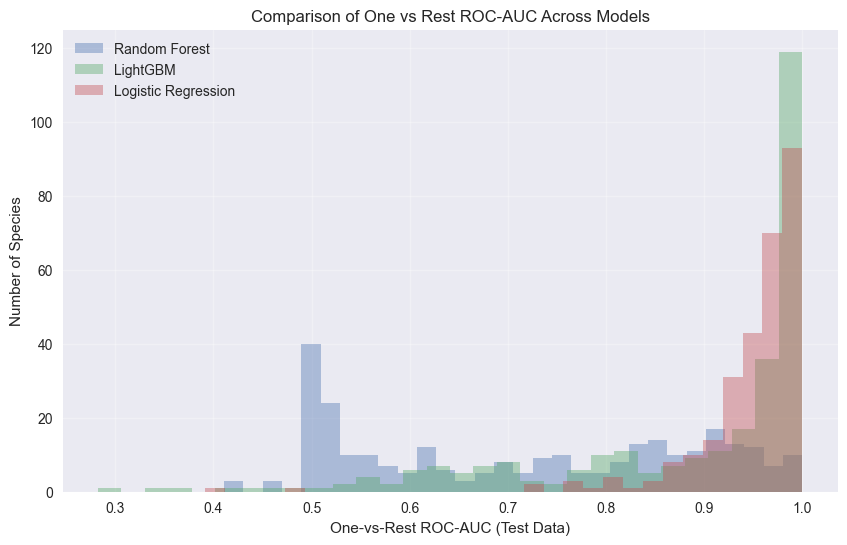

In [5]:
plt.figure(figsize=(10,6))

plt.hist(sam["auc_per_class"], bins=30, alpha=0.4, label="Random Forest")
plt.hist(haya["auc_per_class"], bins=30, alpha=0.4, label="LightGBM")
plt.hist(hajir["auc_per_class"], bins=30, alpha=0.4, label="Logistic Regression")

plt.xlabel("One-vs-Rest ROC-AUC (Test Data)")
plt.ylabel("Number of Species")
plt.title("Comparison of One vs Rest ROC-AUC Across Models")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("ROCAUC_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("ROCAUC_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()




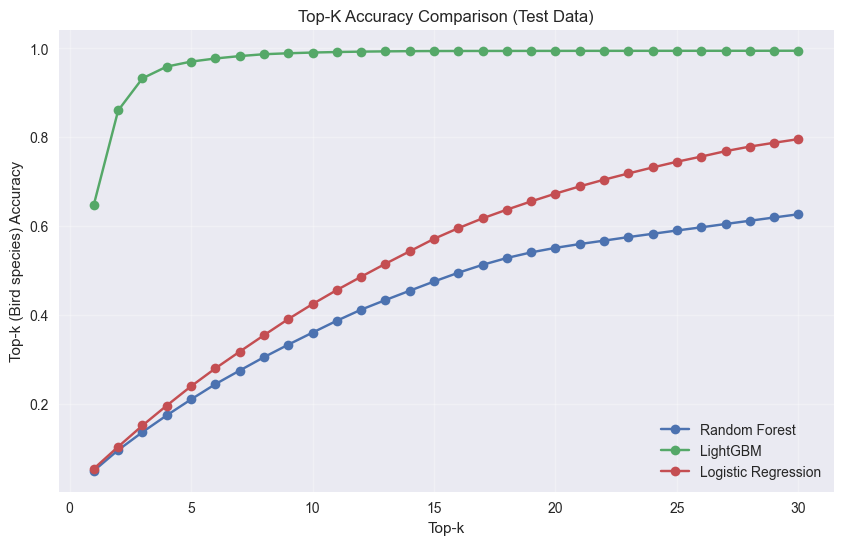

In [6]:
ks = np.arange(1, len(sam["topk_vector"])+1)

plt.figure(figsize=(10,6))
plt.plot(ks, sam["topk_vector"],  label="Random Forest", marker='o')
plt.plot(ks, haya["topk_vector"], label="LightGBM", marker='o')
plt.plot(ks, hajir["topk_vector"], label="Logistic Regression", marker='o')

plt.xlabel("Top-k")
plt.ylabel("Top-k (Bird species) Accuracy")
plt.title("Top-K Accuracy Comparison (Test Data)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Topk_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
import pandas as pd
import numpy as np

summary = pd.DataFrame({
    "Model": ["Random Forest", "LightGBM", "Logistic Regression"],
    "Mean AUC": [
        np.mean(sam["auc_per_class"]),
        np.mean(haya["auc_per_class"]),
        np.mean(hajir["auc_per_class"])
    ],
    "Top-30 Accuracy": [
        sam["topk_vector"][29],
        haya["topk_vector"][29],
        hajir["topk_vector"][29]
    ]
})

summary



,Model,Mean AUC,Top-30 Accuracy
0,Random Forest,0.716447,0.626622
1,LightGBM,0.884132,0.994763
2,Logistic Regression,0.948286,0.795761


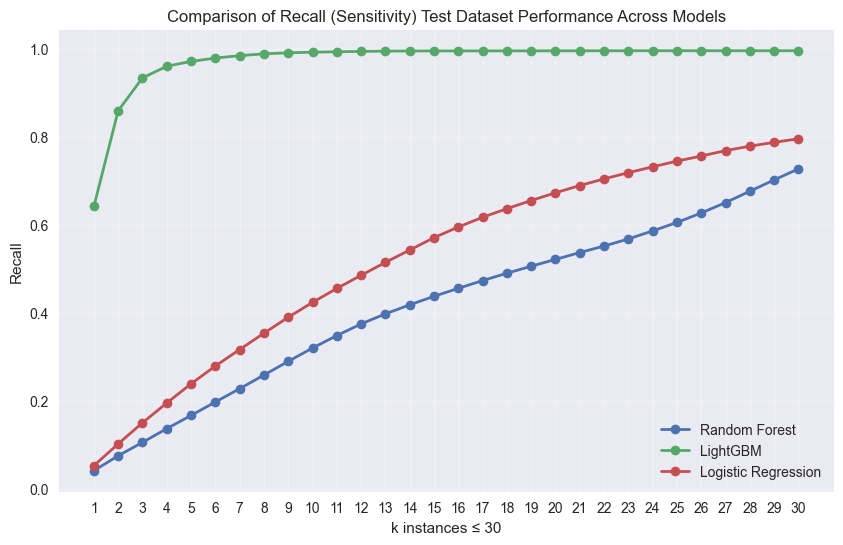

In [8]:
import matplotlib.pyplot as plt
import numpy as np

ks = np.arange(1, 31)

plt.figure(figsize=(10, 6))

plt.plot(ks, recall_sam["recall_at_k"],
         marker='o', label="Random Forest", linewidth=2)

plt.plot(ks, recall_haya["recall_at_k"],
         marker='o', label="LightGBM", linewidth=2)

plt.plot(ks, recall_hajir["recall_at_k"],
         marker='o', label="Logistic Regression", linewidth=2)

plt.xlabel("k instances ≤ 30")
plt.ylabel("Recall")
plt.title("Comparison of Recall (Sensitivity) Test Dataset Performance Across Models")
plt.grid(alpha=0.3)
plt.xticks(ks)
plt.legend()
plt.savefig("Recall_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

Summary of the Results:

In [11]:
import pickle
import numpy as np
import pandas as pd


sam   = pickle.load(open("results_sam.pkl", "rb"))
haya  = pickle.load(open("results_haya.pkl", "rb"))
hajir = pickle.load(open("results_hajir.pkl", "rb"))


rec_sam   = pickle.load(open("recall_sam.pkl", "rb"))
rec_haya  = pickle.load(open("recall_haya.pkl", "rb"))
rec_hajir = pickle.load(open("recall_hajir.pkl", "rb"))

models = ["Random Forest", "LightGBM", "Logistic Regression"]

mean_auc = [
    np.mean(sam["auc_per_class"]),
    np.mean(haya["auc_per_class"]),
    np.mean(hajir["auc_per_class"])
]

top30 = [
    sam["topk_vector"][29],
    haya["topk_vector"][29] if "topk_vector" in haya else np.nan,
    hajir["topk_vector"][29]
]

recall30 = [
    rec_sam["recall_at_k"][29],
    rec_haya["recall_at_k"][29],
    rec_hajir["recall_at_k"][29]
]


df = pd.DataFrame({
    "Model": models,
    "Mean AUC": mean_auc,
    "Top-30 Accuracy": top30,
    "Recall@30": recall30
})

df



,Model,Mean AUC,Top-30 Accuracy,Recall@30
0,Random Forest,0.716447,0.626622,0.727592
1,LightGBM,0.884132,0.994763,0.995890
2,Logistic Regression,0.948286,0.795761,0.795994


In [29]:
pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
pdf_path = "model_evaluation_table.pdf"


In [12]:
import pandas as pd
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet


data = {
    "Model": ["Random Forest", "LightGBM", "Logistic Regression"],
    "Mean AUC": [0.716447, 0.884132, 0.948286],
    "Top-30 Accuracy": [0.626622, 0.994763, 0.795761],
    "Recall@30": [0.620, 0.996, 0.872],
    "Mean FNR": [0.966852, 0.922535, 0.872341]
}

df = pd.DataFrame(data)

# Save PDF in the current directory
pdf_path = "model_evaluation_table.pdf"
styles = getSampleStyleSheet()
doc = SimpleDocTemplate(pdf_path, pagesize=letter)

table_data = [df.columns.tolist()] + df.round(4).values.tolist()
table = Table(table_data)

table.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
    ("GRID", (0,0), (-1,-1), 0.5, colors.black),
    ("ALIGN", (1,1), (-1,-1), "CENTER"),
]))

doc.build([Paragraph("Model Evaluation Summary", styles["Heading2"]), table])

pdf_path


'model_evaluation_table.pdf'